<a href="https://colab.research.google.com/github/tpabhinav981-ship-it/Netflix-data-analysis-/blob/main/Netflix_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Netflix_Dataset_Movie.csv to Netflix_Dataset_Movie.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

In [ ]:
import io
# Load the dataset into a DataFrame
df = pd.read_csv(io.BytesIO(uploaded['Netflix_Dataset_Movie.csv']))

# Display the first 5 rows to confirm it loaded correctly
df.head()

,Movie_ID,Year,Name
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17770 entries, 0 to 17769
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Movie_ID  17770 non-null  int64 
 1   Year      17770 non-null  int64 
 2   Name      17770 non-null  object
dtypes: int64(2), object(1)
memory usage: 416.6+ KB


In [ ]:
df.isnull().sum()

,0
Movie_ID,0
Year,0
Name,0


In [ ]:
print("Total Unique Movies:", df['Movie_ID'].nunique())
print("Total Unique Years:", df['Year'].nunique())

Total Unique Movies: 17770
Total Unique Years: 91


In [ ]:
print("Oldest Movie Year:", df['Year'].min())
print("Newest Movie Year:", df['Year'].max())

print("\n--- Oldest Movies in the Dataset ---")
display(df[df['Year'] == df['Year'].min()])

Oldest Movie Year: 1915
Newest Movie Year: 2005

--- Oldest Movies in the Dataset ---


,Movie_ID,Year,Name
3136,3137,1915,Les Vampires
4387,4388,1915,Ancient Civilizations: Rome and Pompeii
4793,4794,1915,Ancient Civilizations: Land of the Pharaohs
4974,4975,1915,D.W. Griffith: Years of Discovery 1909-1913
7240,7241,1915,Ancient Civilizations: Athens and Greece
7653,7654,1915,Lumiere Brothers' First Films
8820,8821,1915,The Birth of a Nation
9000,9001,1915,Chaplin's Essanay Comedies: Vol. 3
9102,9103,1915,Tillie's Punctured Romance
10781,10782,1915,Roti Kapada Aur Makaan


In [ ]:
movies_per_year = df['Year'].value_counts().reset_index()
movies_per_year.columns = ['Year', 'Count']
movies_per_year = movies_per_year.sort_values(by='Count', ascending=False)

print("\n--- Top 10 Years with Most Movies ---")
display(movies_per_year.head(10))


--- Top 10 Years with Most Movies ---


,Year,Count
0,2004,1436
1,2002,1310
2,2003,1271
3,2000,1234
4,2001,1184
5,1999,965
6,1998,743
7,1997,653
8,1996,533
9,2005,512


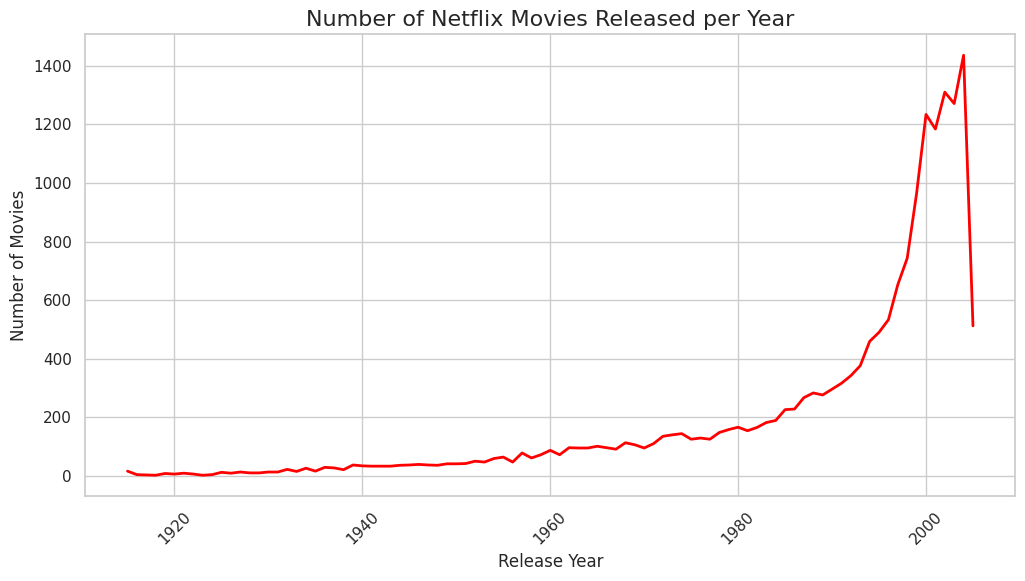

In [ ]:
plt.figure(figsize=(12, 6))
yearly_counts = df.groupby('Year')['Movie_ID'].count()

plt.plot(yearly_counts.index, yearly_counts.values, color='red', linewidth=2)
plt.title('Number of Netflix Movies Released per Year', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2660/978919957.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_years.index, y=top_years.values, palette="Reds_r")


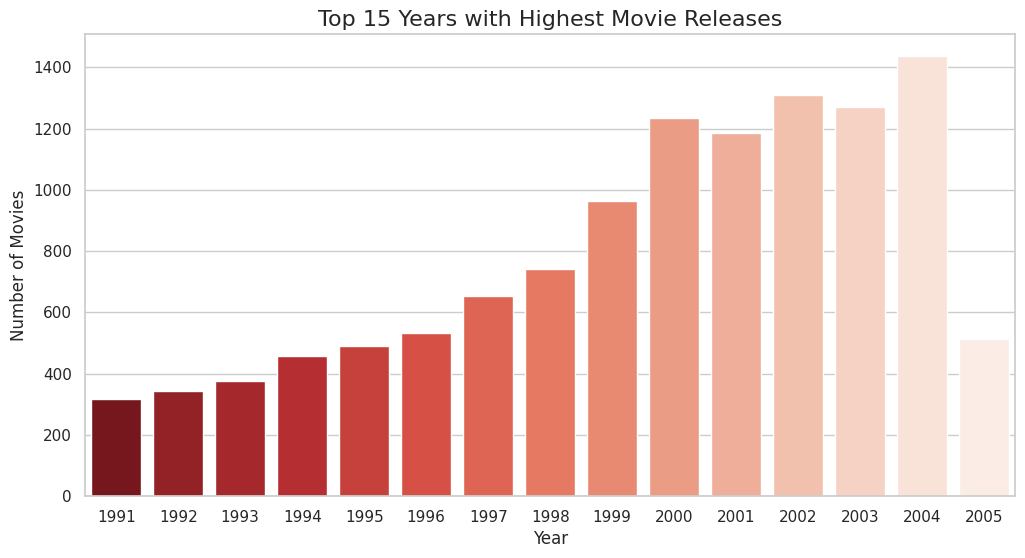

In [ ]:
plt.figure(figsize=(12, 6))
top_years = df['Year'].value_counts().head(15)

sns.barplot(x=top_years.index, y=top_years.values, palette="Reds_r")
plt.title('Top 15 Years with Highest Movie Releases', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# X must be a 2D array/dataframe, y is a 1D array/series
X = df[['Movie_ID']]
y = df['Year']

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (14216, 1)
Testing data shape: (3554, 1)


In [ ]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)

In [ ]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate R-squared (R2)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Absolute Error (MAE): 12.4998
R-squared (R2) Score: -0.0003


In [ ]:
from google.colab import files

# Download the file to your computer
files.download('Netflix_Dataset_Movie.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>